# System-Level Experimental Evaluation and Performance Analysis

I utilized two controlled and secure virtual machines to run a real-world simulation of this pipeline, to assess operability and evaluate its components' performance and value-added.

**Disclaimer**: Some variables in these experiments have been renamed in the latest version of the system code for generalization (e.g., intrusion -> event_triggered), without any change in the system logic (just variable renaming).


----
## A. Experiment 1: Edge-only vs. Cloud-only (Edge Intelligence value: Bandwidth Saving and Latency-Accuracy Trade-off)

I ran two analytics queries for the same video (data/experiment_sample.mp4), isolating where inference takes place.


**Constants:**
| Constant              | Value / meaning |
|-----------------------|----------------|
| skip_interval         | 0 = process every frame |
| heuristic_threshold   | 5.0 = default heuristic change detector |
| video                 | same test video file for both runs (data/experiment_sample.mp4) |

**Edge-only run:**
To force all frames to be processed strictly on the edge I adjusted the following variable:
- `edge_conf_threshold = -1` (lower than the minimum possible), so `(max(confidences) < -1)` is always false: don’t send to the cloud.
- I amended the default logic which sent frames to the cloud automatically if the edge failed to detect anything, i.e., `if not confidences_list: dont send_to_cloud`, to keep the frame locally even if the edge failed to detect.

**Cloud-only run:**
To force the pipeline to send all claims to the cloud I implemented the following adjustments:
- `edge_conf_threshold = 1.1` (higher than the maximum possible), so `(max(confidences) < 1.1)` is always True → always send to the cloud.
- Maintained the default logic in sending frames to the cloud when the edge fails to detect objects (`if not confidences_list: send_to_cloud`).


In [42]:
import matplotlib.pyplot as plt

from e_utilities import (build_dataframe,
                         edge_cloud_comparison,
                         align_data,
                         plot_time_series,
                         heuristic_filter_comparison
                         )


### A.1 CLoud-only Detection

### **Data**

In [43]:
cloud_only = build_dataframe("../experiments/vms_cloud_only/metrics_history.json")

cloud_only.head()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,intrusion,alert_level,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
0,1,0.033333,68.956375,68.956375,2,1,0.500000,0.500000,1,0.052229,True,CRITICAL,8,0.598756,118.304968,118.304968,105.175972,105.175972
1,3,0.100000,17.838478,43.397427,4,2,0.500000,0.500000,2,0.104750,True,CRITICAL,7,0.637229,40.633202,79.469085,32.565832,68.870902
2,4,0.133333,11.793137,32.862663,5,2,0.400000,0.400000,3,0.157629,True,CRITICAL,7,0.613180,40.001869,66.313346,32.743216,56.828340
3,6,0.200000,13.326406,27.978599,7,3,0.428571,0.428571,4,0.210482,True,CRITICAL,7,0.643754,37.774801,59.178710,30.532598,50.254405
4,7,0.233333,17.143011,25.811481,8,3,0.375000,0.375000,5,0.263154,True,CRITICAL,7,0.619211,36.907196,54.724407,29.937983,46.191120


In [44]:
cloud_only.describe()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
count,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000
mean,2749.233099,91.641103,14.970595,13.821019,2750.233099,1610.733099,0.587987,0.587987,1139.500000,58.880521,7.406936,0.560616,37.066795,37.069407,30.243683,30.237082
std,1582.430047,52.747668,6.796142,1.584983,1582.430047,928.399455,0.043744,0.043744,657.746278,34.174740,3.367400,0.124159,3.155833,2.218997,2.886131,2.029939
min,1.000000,0.033333,10.868549,13.075461,2.000000,1.000000,0.250000,0.250000,1.000000,0.052229,0.000000,0.000000,31.985044,36.586106,26.200056,29.688256
25%,1399.250000,46.641667,12.183189,13.357217,1400.250000,830.000000,0.568341,0.568341,570.250000,28.986201,5.000000,0.480573,34.580767,36.793629,27.694404,30.006558
50%,2883.500000,96.116667,13.290167,13.491443,2884.500000,1745.000000,0.590346,0.590346,1139.500000,58.712386,7.000000,0.539634,37.368536,36.881280,30.562043,30.071223
75%,4271.500000,142.383333,14.848948,14.174896,4272.500000,2563.750000,0.601116,0.601116,1708.750000,88.799738,10.000000,0.614356,38.895309,37.005394,32.015920,30.189686
max,5107.000000,170.233333,68.956375,68.956375,5108.000000,2830.000000,0.855072,0.855072,2278.000000,117.750935,19.000000,0.967537,118.304968,118.304968,105.175972,105.175972




#### **Final Snapshot Metrics**

**Total frames processed**

In [45]:
cloud_only[-1:]["total_frames_processed"]

2277    5108
Name: total_frames_processed, dtype: int64

**Frames sent to the cloud**

In [46]:
cloud_only[-1:]["frames_sent_to_cloud"]

2277    2278
Name: frames_sent_to_cloud, dtype: int64

**Total data sent/ bandwidth usage (MB)**

In [47]:
cloud_mb = cloud_only[-1:]["mb_sent_to_cloud"]

cloud_mb

2277    117.750935
Name: mb_sent_to_cloud, dtype: float64

**Heuristic filter drop ratio**

In [48]:
cloud_only[-1:]["heuristic_drop_ratio"]

2277    0.554033
Name: heuristic_drop_ratio, dtype: float64

**Cloud avoidance ratio**

In [49]:
cloud_only[-1:]["cloud_avoidance_ratio"]

2277    0.554033
Name: cloud_avoidance_ratio, dtype: float64

**Note**

This is due to the 5.0 default heuristic filter = heuristic drop ratio. Meaning all frames, that were not dropped heuristically were send to the cloud for processing.

----

**Latency (avg round-trip)**

In [50]:
cloud_only[-1:]["avg_rt_ms"]

2277    37.066795
Name: avg_rt_ms, dtype: float64

**Edge gateway avg infer time (ms)**

In [51]:
cloud_only[-1:]["avg_edge_inference_ms"]

2277    14.970595
Name: avg_edge_inference_ms, dtype: float64

**Important Note**

Edge model serves as a decision gateway in this setup, the decision is always send to the cloud. This doesn't impact the round-trip latency of the cloud server, as the round-tip latency is measured after this gateway.

---------------------
-------

### A.2 Edge-only Detection

### **Data**

In [52]:
edge_only_raw = build_dataframe("../experiments/vms_edge_only/metrics_history.json")
edge_only_raw.head()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,intrusion,alert_level,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
0,1,0.033333,75.465202,75.465202,2,1,0.500000,1.0,0,0.0,True,CRITICAL,9,0.490358,0.0,0.0,0.0,0.0
1,3,0.100000,20.239353,47.852278,4,2,0.500000,1.0,0,0.0,True,CRITICAL,7,0.565866,0.0,0.0,0.0,0.0
2,4,0.133333,12.104750,35.936435,5,2,0.400000,1.0,0,0.0,True,CRITICAL,7,0.589780,0.0,0.0,0.0,0.0
3,6,0.200000,12.522697,30.083001,7,3,0.428571,1.0,0,0.0,True,CRITICAL,8,0.586682,0.0,0.0,0.0,0.0
4,7,0.233333,11.076212,26.281643,8,3,0.375000,1.0,0,0.0,True,CRITICAL,8,0.583936,0.0,0.0,0.0,0.0


In [53]:
edge_only_raw.describe()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
count,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000
mean,2749.233099,91.641103,16.492439,16.010881,2750.233099,1610.733099,0.587987,0.999820,0.663740,0.031731,5.385206,0.530502,12.289909,12.690184,10.153103,10.454513
std,1582.256335,52.741878,9.232577,2.402022,1582.256335,928.297540,0.043740,0.000281,1.019981,0.048453,2.619146,0.138895,18.536033,19.096894,15.328944,15.733687
min,1.000000,0.033333,10.175467,13.119608,2.000000,1.000000,0.250000,0.998966,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1399.000000,46.633333,12.330353,14.528348,1400.000000,830.000000,0.568336,0.999550,0.000000,0.000000,4.000000,0.440544,0.000000,0.000000,0.000000,0.000000
50%,2883.500000,96.116667,13.611197,16.811133,2884.500000,1745.000000,0.590346,1.000000,0.000000,0.000000,5.000000,0.498534,0.000000,0.000000,0.000000,0.000000
75%,4272.000000,142.400000,15.496850,17.160547,4273.000000,2564.000000,0.601124,1.000000,2.000000,0.096952,7.000000,0.582996,39.081335,41.189909,32.117367,33.877492
max,5107.000000,170.233333,89.071274,89.071274,5108.000000,2830.000000,0.855072,1.000000,3.000000,0.136736,16.000000,0.968554,45.223236,43.298483,38.203955,35.637617


#### Drop the older run entries

**Why** I conducted two runs for edge-only configuration (total of 4556 history entries). The first one was inaccurate, due to frame leakages to the cloud through  this logic gate `(if not confidences_list: send_to_cloud)` in cloud decision, resulted in sending few frames to the cloud. I corrected it in the second run.

In [54]:
edge_only_raw.drop(edge_only_raw.index[:2278], inplace=True)
# Drop old run logs
edge_only_raw.reset_index(drop=True, inplace=True)

edge_only = edge_only_raw

In [55]:
edge_only.head()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,intrusion,alert_level,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
0,1,0.033333,89.071274,89.071274,2,1,0.500000,1.0,0,0.0,True,CRITICAL,9,0.490358,0.0,0.0,0.0,0.0
1,3,0.100000,18.060207,53.565741,4,2,0.500000,1.0,0,0.0,True,CRITICAL,7,0.565866,0.0,0.0,0.0,0.0
2,4,0.133333,11.140585,39.424022,5,2,0.400000,1.0,0,0.0,True,CRITICAL,7,0.589780,0.0,0.0,0.0,0.0
3,6,0.200000,13.914585,33.046663,7,3,0.428571,1.0,0,0.0,True,CRITICAL,8,0.586682,0.0,0.0,0.0,0.0
4,7,0.233333,22.495508,30.936432,8,3,0.375000,1.0,0,0.0,True,CRITICAL,8,0.583936,0.0,0.0,0.0,0.0


In [56]:
edge_only.describe()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
count,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.000000,2278.0,2278.0,2278.0,2278.000000,2278.000000,2278.0,2278.0,2278.0,2278.0
mean,2749.233099,91.641103,17.512837,17.449706,2750.233099,1610.733099,0.587987,1.0,0.0,0.0,5.384548,0.530323,0.0,0.0,0.0,0.0
std,1582.430047,52.747668,10.432529,2.063411,1582.430047,928.399455,0.043744,0.0,0.0,0.0,2.620578,0.139311,0.0,0.0,0.0,0.0
min,1.000000,0.033333,11.022329,16.746128,2.000000,1.000000,0.250000,1.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,1399.250000,46.641667,12.719274,16.952927,1400.250000,830.000000,0.568341,1.0,0.0,0.0,4.000000,0.440443,0.0,0.0,0.0,0.0
50%,2883.500000,96.116667,13.978720,17.131582,2884.500000,1745.000000,0.590346,1.0,0.0,0.0,5.000000,0.498516,0.0,0.0,0.0,0.0
75%,4271.500000,142.383333,15.836656,17.388508,4272.500000,2563.750000,0.601116,1.0,0.0,0.0,7.000000,0.582933,0.0,0.0,0.0,0.0
max,5107.000000,170.233333,89.071274,89.071274,5108.000000,2830.000000,0.855072,1.0,0.0,0.0,16.000000,0.968554,0.0,0.0,0.0,0.0



#### **Final  Snapshot Metrics**

**Total frames processed**

In [57]:
edge_only[-1:]["total_frames_processed"]

2277    5108
Name: total_frames_processed, dtype: int64

**Frames sent to the cloud**

In [58]:
edge_only[-1:]["frames_sent_to_cloud"]

2277    0
Name: frames_sent_to_cloud, dtype: int64

**Total data sent/ bandwidth usage (MB)**

In [59]:
edge_mb = edge_only[-1:]["mb_sent_to_cloud"]

edge_mb

2277    0.0
Name: mb_sent_to_cloud, dtype: float64

**Heuristic filter drop ratio**

In [60]:
edge_only[-1:]["heuristic_drop_ratio"]

2277    0.554033
Name: heuristic_drop_ratio, dtype: float64

**Cloud avoidance ratio**

In [61]:
edge_only[-1:]["cloud_avoidance_ratio"]

2277    1.0
Name: cloud_avoidance_ratio, dtype: float64

**Note**

Zero frames send to the cloud, all processed locally on-edge.


**2.6 Latency (avg round-trip)**

In [62]:
edge_only[-1:]["avg_rt_ms"]

2277    0.0
Name: avg_rt_ms, dtype: float64

**Average edge infer time latency**

In [63]:
edge_only[-1:]["avg_edge_inference_ms"]

2277    17.512837
Name: avg_edge_inference_ms, dtype: float64

**Observation**

Zero RT latency as no frames were sent to the cloud. Edge average inference time is the only latency in this scenario.

------
### Analysis:  Bandwidth usage comparison (edg-only vs. cloud-only)

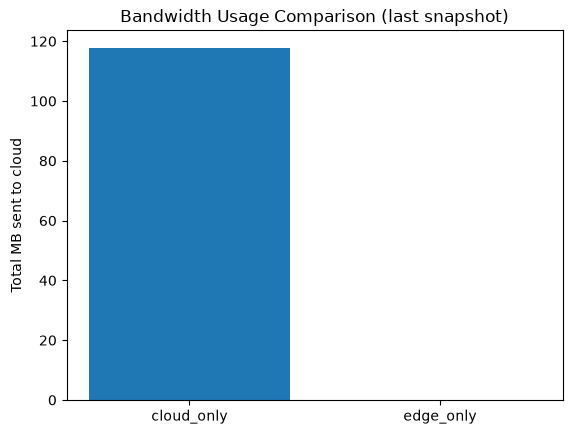

,Metric,Edge-only,cloud_only
0,Total Frames Processed,5108.00,5108.00
1,Cloud Avoidance Ratio,1.00,0.55
2,Heuristic Drop Ratio,0.55,0.55
3,Frames Sent to Cloud,0.00,2278.00
4,Bandwidth Sent (MB),0.00,117.75


In [64]:
edge_cloud_comparison(edge_only=edge_only, cloud_only=cloud_only, )

---
### Analysis: Latency and Detection Quality (Number of objects and Accuracy)

In [65]:
aligned_df = align_data(edge_df=edge_only, cloud_df=cloud_only)

aligned_df

,frame_index,count_e,avg_conf_e,lat_e,count_c,avg_conf_c,lat_c
0,1,9,0.490358,89.071274,8,0.598756,118.304968
1,3,7,0.565866,18.060207,7,0.637229,40.633202
2,4,7,0.589780,11.140585,7,0.613180,40.001869
3,6,8,0.586682,13.914585,7,0.643754,37.774801
4,7,8,0.583936,22.495508,7,0.619211,36.907196
...,...,...,...,...,...,...,...
2273,5103,4,0.671710,11.582851,8,0.591394,38.295746
2274,5104,4,0.697307,11.788130,6,0.644566,40.247917
2275,5105,6,0.588741,12.051105,6,0.655564,39.006948
2276,5106,4,0.712261,11.990786,6,0.663139,39.318562


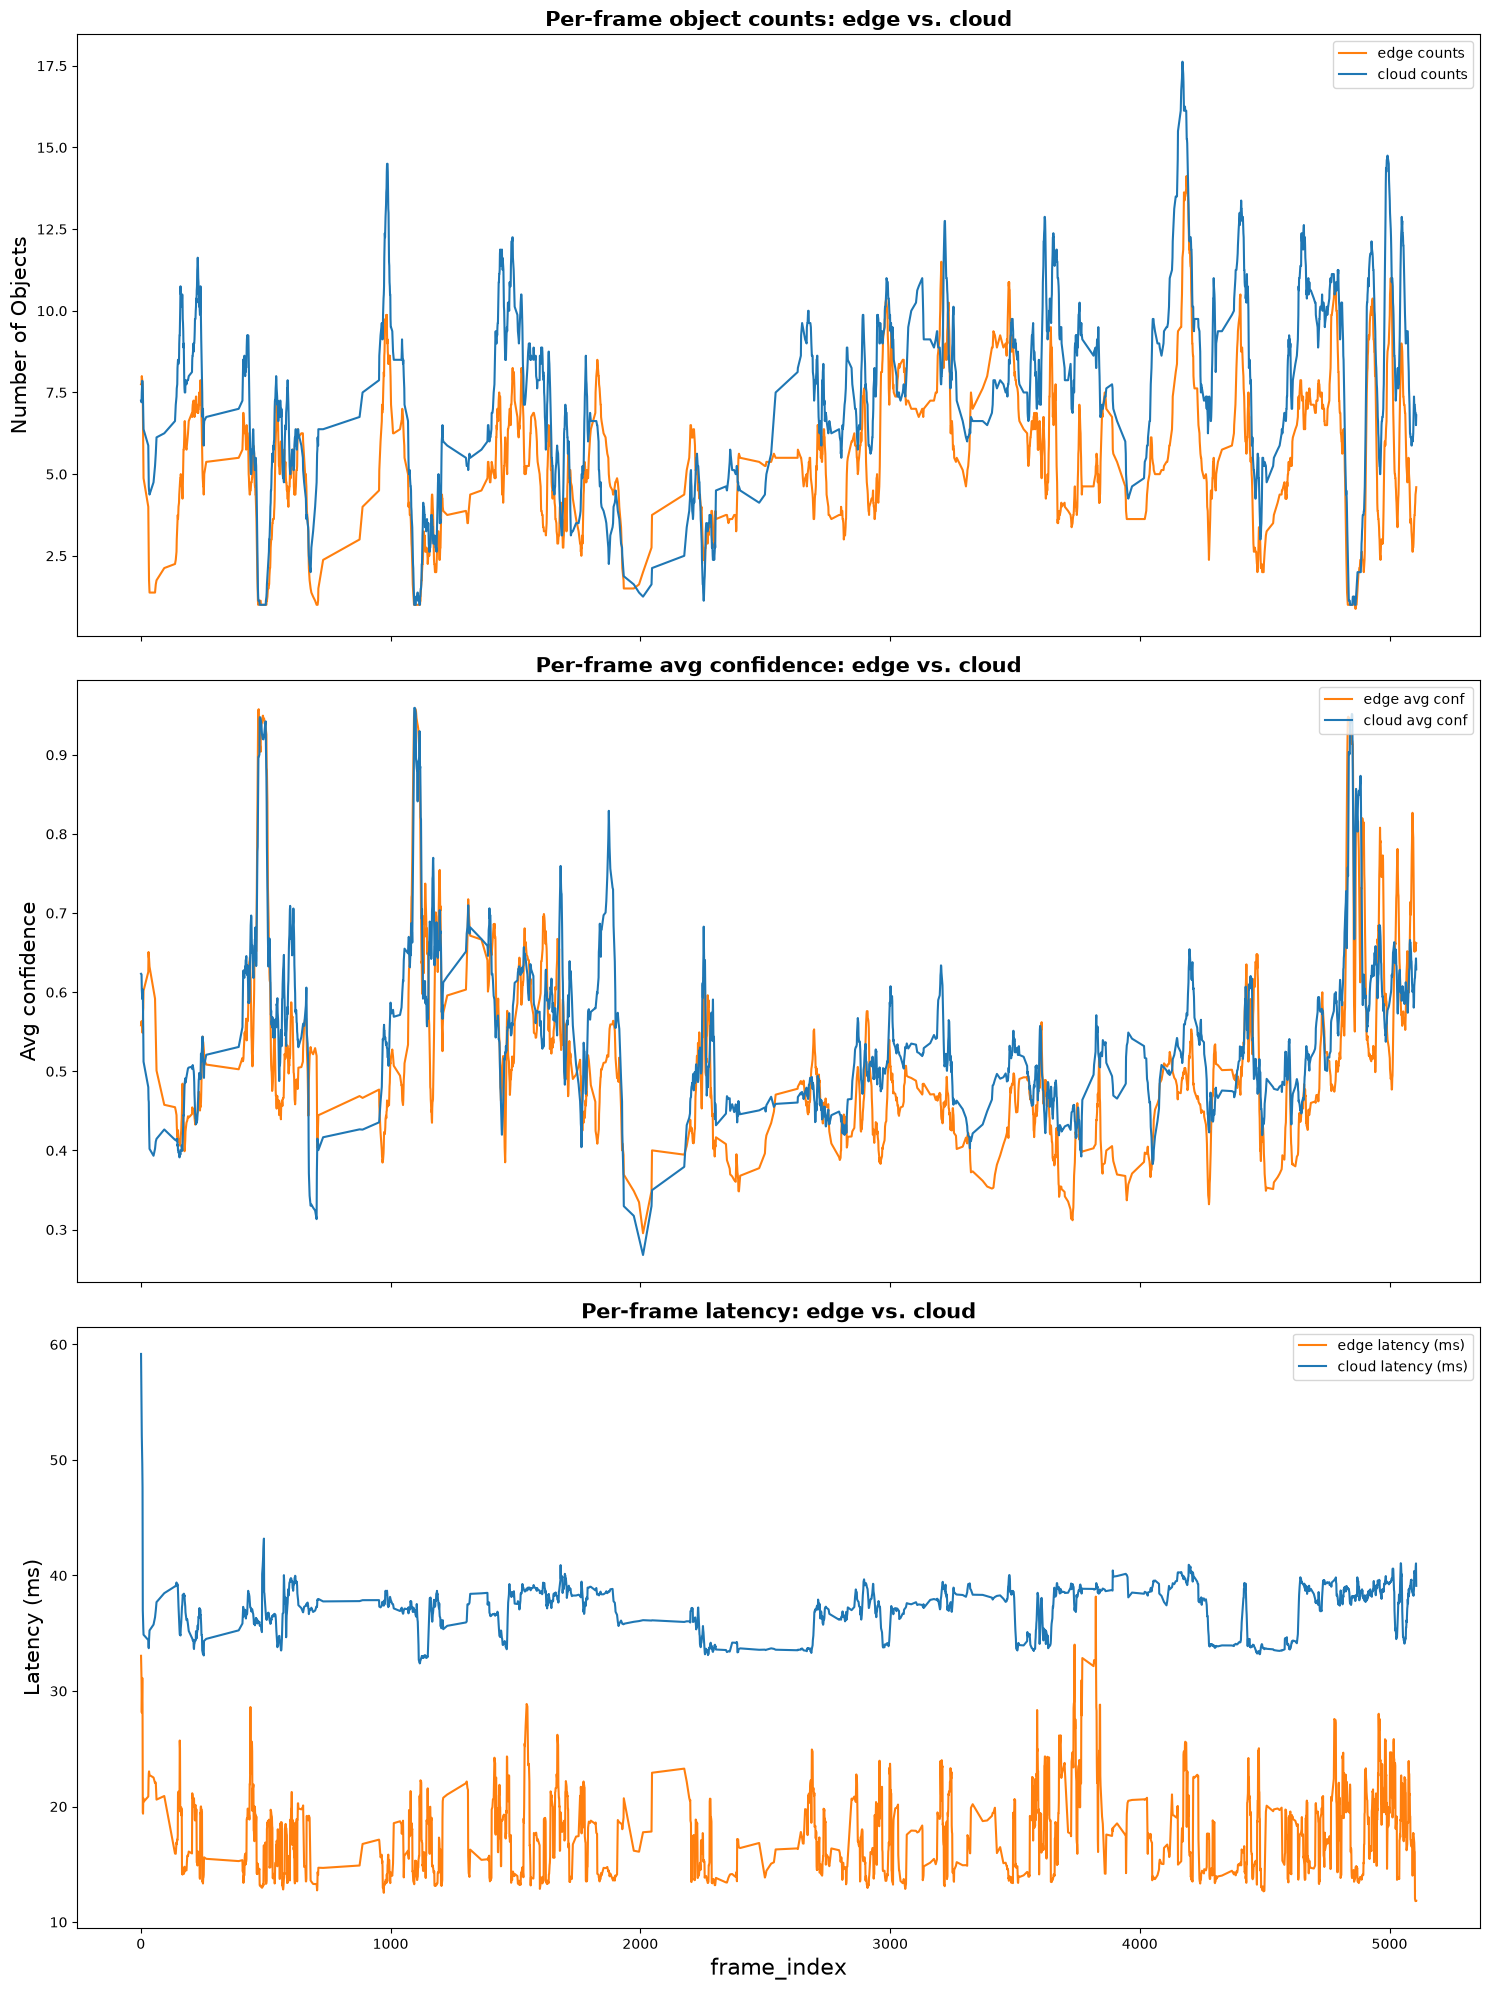

In [66]:
plot_time_series(merged_df=aligned_df, smooth_window=8)

----------------
------

--------

## B. Experiment 2: Heuristic Filter Impact

**Constants:**
| Constant              | Value / meaning |
|-----------------------|----------------|
| skip_interval         | 0 = process every frame |
| edge_conf_threshold   | 0.70 = default value |
| video                 | same test video file for both runs (data/experiment_sample.mp4) |







**Objective:**
Show how the heuristic change detection filter reduces unnecessary frame processing and cloud offloading, and improves overall efficiency.

**Datasets:**

Heuristic OFF: heuristic_threshold = 0 (process all frames).

Heuristic ON default: heuristic_threshold = 5 (process only significant changes).





### B.1 Heuristic filter OFF (value 0)

### **Data**

In [67]:
heuristic_off_df = build_dataframe("../experiments/vms_heuristic_off_0.0/metrics_history.json")

In [68]:
heuristic_off_df.head()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,intrusion,alert_level,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
0,1,0.033333,67.244053,67.244053,2,1,0.500000,1.0,0,0.0,True,CRITICAL,9,0.490358,0.0,0.0,0.0,0.0
1,2,0.066667,50.594330,58.919191,3,1,0.333333,1.0,0,0.0,True,CRITICAL,9,0.500085,0.0,0.0,0.0,0.0
2,3,0.100000,16.119957,44.652780,4,1,0.250000,1.0,0,0.0,True,CRITICAL,7,0.565866,0.0,0.0,0.0,0.0
3,4,0.133333,10.238409,36.049187,5,1,0.200000,1.0,0,0.0,True,CRITICAL,7,0.589780,0.0,0.0,0.0,0.0
4,5,0.166667,15.526772,31.944704,6,1,0.166667,1.0,0,0.0,True,CRITICAL,7,0.570030,0.0,0.0,0.0,0.0


In [69]:
heuristic_off_df.describe()

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
count,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.0,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000,5107.000000
mean,2554.000000,85.133333,15.040895,14.402037,2555.000000,1.0,0.001589,0.469309,1321.709223,68.040380,6.045624,0.509155,38.244695,37.890949,31.260122,31.044212
std,1474.408243,49.146941,7.736715,1.307914,1474.408243,0.0,0.011124,0.088350,791.081004,40.650866,2.870981,0.124422,3.306920,1.700128,3.060272,1.400032
min,1.000000,0.033333,9.953976,13.163984,2.000000,1.0,0.000196,0.205128,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1277.500000,42.583333,11.951804,13.833997,1278.500000,1.0,0.000261,0.450856,670.000000,34.539189,4.000000,0.440657,36.809921,37.891058,29.855490,30.996475
50%,2554.000000,85.133333,13.084412,14.540947,2555.000000,1.0,0.000391,0.473368,1307.000000,67.178248,6.000000,0.494810,38.872480,37.968431,31.976223,31.124725
75%,3830.500000,127.683333,14.591336,14.804275,3831.500000,1.0,0.000782,0.497993,2018.000000,103.812654,8.000000,0.557442,39.512873,38.086625,32.371044,31.220407
max,5107.000000,170.233333,67.244053,67.244053,5108.000000,1.0,0.500000,1.000000,2588.000000,133.122040,19.000000,0.968554,70.779085,46.639204,63.327789,37.699938



### Final Snapshot Metrics

**Heuristic filter drop ratio**

In [70]:
heuristic_off_df[-1:]["heuristic_drop_ratio"]

5106    0.000196
Name: heuristic_drop_ratio, dtype: float64


**Number of frames heuristically dropped**

In [71]:
heuristic_off_df[-1:]["heuristic_frames_dropped"]

5106    1
Name: heuristic_frames_dropped, dtype: int64

**Rationale:**

**Why 1?** When the orchestrator initializes the heuristic filter, the logic skips further processing for the first frame using (if first frame: continue), meaning no object detection is performed on the first frame. This is because the heuristic requires two frames to compute the difference, so the first frame is only stored as a reference to compare with the second frame. However, this first frame is still counted in the total processed frames. Since no detection is performed on it. It appears as a “dropped” frame in the statistics, where: (Heretic dropped = total processed – total underwent object detection) in this case. So, even with the heuristic filter switched off (threshold = 0), there will always be 1 heuristically ignored/dropped frame due to the initialization logic.


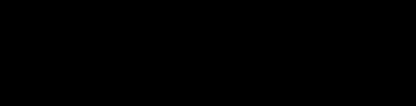
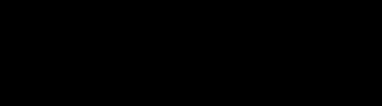
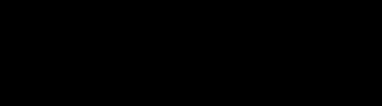
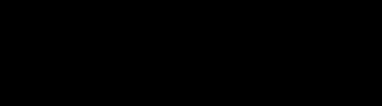
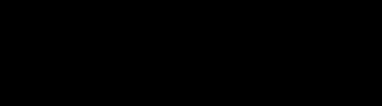
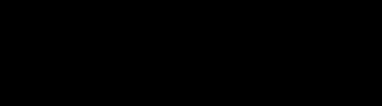

**Total frames processed**


In [72]:
heuristic_off_df[-1:]["total_frames_processed"]

5106    5108
Name: total_frames_processed, dtype: int64

**Total bandwidth usage (MB)**

In [73]:
heuristic_off_df[-1:]["mb_sent_to_cloud"]

5106    133.12204
Name: mb_sent_to_cloud, dtype: float64

**Frames sent to the cloud**

In [74]:
heuristic_off_df[-1:]["frames_sent_to_cloud"]

5106    2588
Name: frames_sent_to_cloud, dtype: int64

-----
### B.2 Heuristic filter ON (default value 5.0)

In [75]:
heuristic_on_df = build_dataframe("../experiments/vms_heuristic_default_5.0/metrics_history.json")
heuristic_on_df

,frame_index,timestamp,edge_inference_ms,avg_edge_inference_ms,total_frames_processed,heuristic_frames_dropped,heuristic_drop_ratio,cloud_avoidance_ratio,frames_sent_to_cloud,mb_sent_to_cloud,intrusion,alert_level,objects_count,frame_mean_conf,round_trip_time_ms,avg_rt_ms,cloud_infer_ms,avg_cloud_infer_ms
0,1,0.033333,69.700003,69.700003,2,1,0.500000,1.000000,0,0.000000,True,CRITICAL,9,0.490358,0.000000,0.000000,0.000000,0.000000
1,3,0.100000,46.210527,57.955265,4,2,0.500000,1.000000,0,0.000000,True,CRITICAL,7,0.565866,0.000000,0.000000,0.000000,0.000000
2,4,0.133333,12.368917,42.759816,5,2,0.400000,1.000000,0,0.000000,True,CRITICAL,7,0.589780,0.000000,0.000000,0.000000,0.000000
3,6,0.200000,12.680292,35.239935,7,3,0.428571,1.000000,0,0.000000,True,CRITICAL,8,0.586682,0.000000,0.000000,0.000000,0.000000
4,7,0.233333,11.498928,30.491734,8,3,0.375000,1.000000,0,0.000000,True,CRITICAL,8,0.583936,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,5103,170.100000,12.936592,15.972585,5104,2830,0.554467,0.851097,760,39.388511,True,CRITICAL,4,0.671710,33.182383,37.011082,26.943922,30.155061
2274,5104,170.133333,12.047291,15.970860,5105,2830,0.554358,0.851126,760,39.388511,True,CRITICAL,4,0.697307,33.182383,37.011082,26.943922,30.155061
2275,5105,170.166667,11.347294,15.968829,5106,2830,0.554250,0.851156,760,39.388511,True,CRITICAL,6,0.588741,33.182383,37.011082,26.943922,30.155061
2276,5106,170.200000,11.622906,15.966920,5107,2830,0.554141,0.851185,760,39.388511,True,CRITICAL,4,0.712261,33.182383,37.011082,26.943922,30.155061


**Heuristic filter drop ratio**

In [76]:
heuristic_on_df[-1:]["heuristic_drop_ratio"]

2277    0.554033
Name: heuristic_drop_ratio, dtype: float64

**Number of frames heuristically dropped**

In [77]:
heuristic_on_df[-1:]["heuristic_frames_dropped"]

2277    2830
Name: heuristic_frames_dropped, dtype: int64

**Total frames processed**


In [78]:
heuristic_on_df[-1:]["total_frames_processed"]

2277    5108
Name: total_frames_processed, dtype: int64

**Total bandwidth usage (MB)**

In [79]:
heuristic_on_df[-1:]["mb_sent_to_cloud"]

2277    39.388511
Name: mb_sent_to_cloud, dtype: float64

**Frames sent to the cloud**

In [80]:
heuristic_on_df[-1:]["frames_sent_to_cloud"]

2277    760
Name: frames_sent_to_cloud, dtype: int64

**Observation**

The heuristic filter value range is 0-255, setting it to a small value provided huge gains in terms of reduced workload ~ %55 less workload.

-----

### Analysis: Heuristic filter on/off comparison

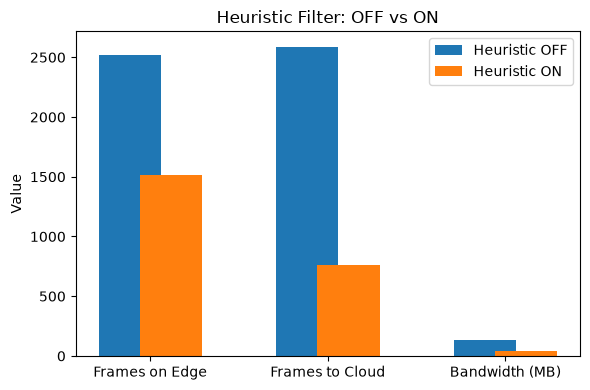

,Metric,Heuristic OFF,Heuristic ON
0,Total Frames Processed,5108.00,5108.00
1,Heuristically dropped Frames,1.00,2830.00
2,Heuristic Drop Ratio,0.00,0.55
3,Frames processed on edge,2519.00,1518.00
4,Frames Sent to Cloud,2588.00,760.00
5,Bandwidth Sent (MB),133.12,39.39


In [81]:
heuristic_filter_comparison(heuristic_on_df=heuristic_on_df,heuristic_off_df=heuristic_off_df)

--------------